In [2]:
import warnings
warnings.filterwarnings('ignore')
import torch
dtype = torch.float
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
import matplotlib.pyplot as plt, numpy as np
from tifffile import imread
import sys
sys.path.append(sys.path.append('../../'))

from lib.hdn.gaussianMixtureNoiseModel import GaussianMixtureNoiseModel
from lib.hdn import histNoiseModel
from lib.hdn.utils import plotProbabilityDistribution
from lib.utils.data_utils import crop_center
import os
from pathlib import Path

In [25]:
# Data paths
baseDir = Path(r"E:\dl_monalisa")
dataDir = baseDir / "Data"
noiseModelsDir = baseDir / "noiseModels"
dataset = "Vim_fixed_mltplSNR_30nm"
data_path_signal = dataDir / dataset / r"inference\N2V\Vim_fixed_Avg1-3_no_clipping"
data_path_obs = dataDir / dataset / r"dump\rec\timelapses_gathered"# r"dump\rec\timelapses_gathered" 

# Parameters
noise_level = 0 # "all",list of int, or int
signalIdx = 1

# to create avg signal on the fly
createAvgSig = False
createAvgSig_nFrames = 1 # int or "all"

normSig2Obs = False
normalizeEverything = False
clip = 0 # False or clip value
crop_size = None #(1200,1200)
display = True # display images and histograms or not
hist_bins = 256


# noise model Load
noiseModel_path = r"E:\dl_monalisa\NoiseModels\Noise0_SigN2Vavg_Clip-3_norm_bis\GMM.npz"
noiseModel_params= np.load(noiseModel_path)
noiseModel = GaussianMixtureNoiseModel(params = noiseModel_params, device = device)

In [26]:
#print some noise model info
ngaussian = noiseModel.n_gaussian
n_coeff = noiseModel.n_coeff
min_signal = noiseModel.min_signal
max_signal = noiseModel.max_signal

print(
    f" #gaussians: {ngaussian}\n",
    f"#coeffs: {n_coeff}\n",
    f"min: {min_signal.item()}\n",
    f"max: {max_signal.item()}",
)


 #gaussians: 5
 #coeffs: 6
 min: -0.36564990878105164
 max: 34.567718505859375


In [27]:
### LOAD DATA ###

signal = []
observation = []
filters = ['tif','tiff']

files_signal = os.listdir(data_path_signal)
for f in files_signal:
    if f.split('.')[-1] not in filters:
        print(f"removing {f} in signals because not in filters")
        files_signal.remove(f)

if data_path_obs != "same":
    files_obs = os.listdir(data_path_obs)
    for f in files_obs:
        if f.split('.')[-1] not in filters:
            print(f"Removing {f} in observations because not in filters")
            files_obs.remove(f)

    assert len(files_obs) == len(files_signal)
    print(f"\nFound {len(files_signal)} files.\n")

for i in range (len(files_signal)):
    file_signal = files_signal[i]
    if data_path_obs == "same":
        file_obs = file_signal
    else:
        file_obs = files_obs [i]
    
    # signal idx selection (if applicable)
    if not createAvgSig:
        if isinstance(signalIdx,int):
            im_signal = imread(data_path_signal / file_signal)[signalIdx]
        else:
            im_signal = imread(data_path_signal / file_signal)
    else:
        im_signal = imread(data_path_signal / file_signal)
        assert len(im_signal.shape) == 3, "Create avg signal impossible if signal not 3D stack!"
        im_signal = np.mean(im_signal[:min(im_signal.shape[0],createAvgSig_nFrames)],axis=0)
        
    # noise level selection
    if noise_level == "all":
        im_obs  = imread(data_path_obs / file_obs)
    elif isinstance(noise_level,int) or isinstance(noise_level,list):
        try:
            im_obs = imread(data_path_obs / file_obs)[noise_level]
        except IndexError:
            print(f"Image {f} ignored because of IndexError") 
            continue

    if not isinstance(clip,bool):
        im_obs[im_obs<clip] = clip
        im_signal[im_signal<clip] = clip

    if crop_size is not None:
        im_obs = crop_center(im_obs,crop_size)
        im_signal = crop_center(im_signal,crop_size)

    observation.append(im_obs)
    signal.append(im_signal)

    print(f"Signal {file_signal}: Observation {file_obs}:\t Shape: {im_obs.shape}")





Found 25 files.

Signal img_and_denoised_00.tiff: Observation rec_c01_rec_CAM.tiff:	 Shape: (1416, 1392)
Signal img_and_denoised_01.tiff: Observation rec_c02_rec_CAM.tiff:	 Shape: (1416, 1392)
Signal img_and_denoised_02.tiff: Observation rec_c03_rec_CAM.tiff:	 Shape: (1416, 1392)
Signal img_and_denoised_03.tiff: Observation rec_c04_rec_CAM.tiff:	 Shape: (1416, 1392)
Signal img_and_denoised_04.tiff: Observation rec_c05_rec_CAM.tiff:	 Shape: (1416, 1392)
Signal img_and_denoised_05.tiff: Observation rec_c07_rec_CAM.tiff:	 Shape: (1416, 1392)
Signal img_and_denoised_06.tiff: Observation rec_c08_rec_CAM.tiff:	 Shape: (1416, 1392)
Signal img_and_denoised_07.tiff: Observation rec_c09_rec_CAM.tiff:	 Shape: (1416, 1392)
Signal img_and_denoised_08.tiff: Observation rec_c10_rec_CAM.tiff:	 Shape: (1416, 1392)
Signal img_and_denoised_09.tiff: Observation rec_c11_rec_CAM.tiff:	 Shape: (1416, 1392)
Signal img_and_denoised_10.tiff: Observation rec_c12_rec_CAM.tiff:	 Shape: (1416, 1392)
Signal img_and

In [28]:

# fullSig = []
# fullObs = []
# for i,obs in enumerate(observation):
#     sig = signal[i]
#     if normSig2Obs:
#         sig = (sig - np.mean(sig))/np.std(sig)
#     for frame in obs:
#         if normSig2Obs:
#             fullSig.append(sig * np.std(frame) + np.mean(frame))
#         else:
#             fullSig.append(sig)
#         fullObs.append(frame)

# fullSig = []
# fullObs = []
# for i,obs in enumerate(observation):
#     sig = signal[i]
#     sig = (sig - np.mean(sig))/np.std(sig)
#     fullSig.append(sig * np.std(obs) + np.mean(obs))

# fullSig = signal
# fullObs = observation
# signal = np.stack(fullSig)
# observation = np.stack(fullObs)


signal = np.stack(signal)
observation = np.stack(observation)

avgObs = np.mean(observation)
stdObs = np.std(observation)

normalizeEverything = True
if normalizeEverything:
    signal = (signal - np.mean(signal))/np.std(signal)
    observation = (observation - np.mean(observation))/np.std(observation)


minVal = np.min(signal)
maxVal = np.max(signal)

print(f"\n\nConcatenated arrays: Signal: {signal.shape} Observation: {observation.shape}")




Concatenated arrays: Signal: (25, 1416, 1392) Observation: (25, 1416, 1392)


In [6]:
print(avgObs,stdObs)

21.185982 37.89199


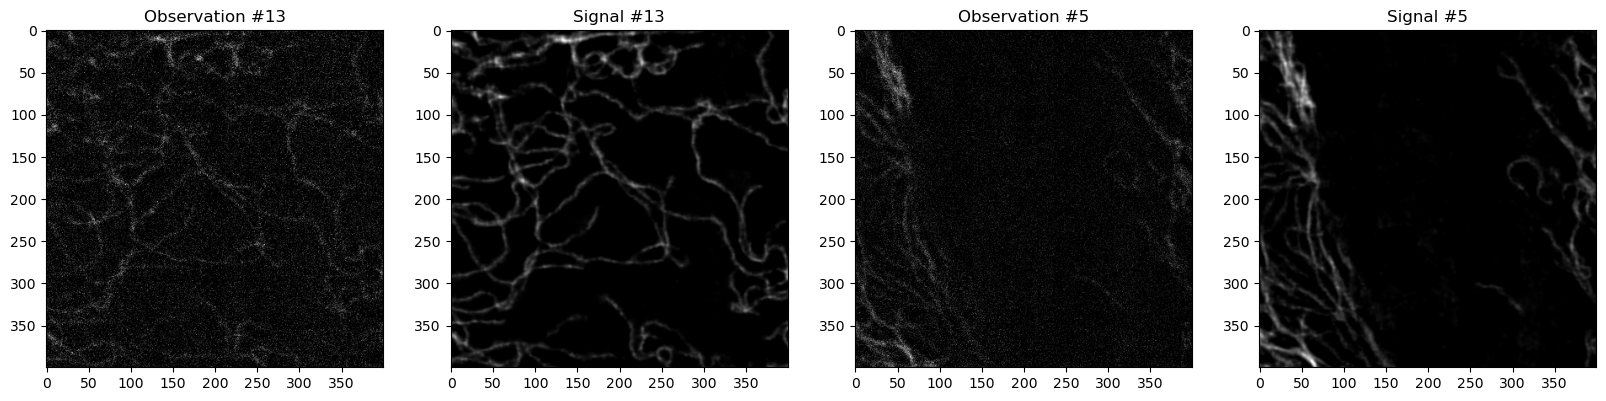

In [29]:
# Display examples of signals and observations if display is set to True

crop_size = 400
h,w = signal[0].shape

starty,startx = h//2-crop_size//2, w//2-crop_size//2
stopy,stopx = h//2+crop_size//2,w//2+crop_size//2

if display:
    idxs = np.random.randint(0,observation.shape[0],2)
    plt.figure(figsize=(20,10))
    for i in range(len(idxs)):
        sig = signal[idxs[i],starty:stopy,starty:stopy]
        obs = observation[idxs[i],starty:stopy,starty:stopy]
        plt.subplot(1,4,2*i+1)
        plt.imshow(obs,cmap="gray")
        plt.title(f"Observation #{idxs[i]}")
        plt.subplot(1,4,2*i+2)
        plt.imshow(sig,cmap="gray")
        plt.title(f"Signal #{idxs[i]}")

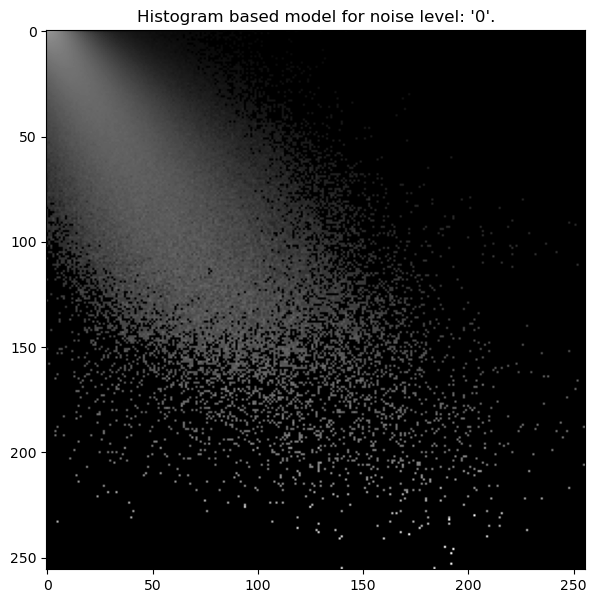

In [30]:
# Create histogram-based model

plt.figure(figsize=(7,7))
histogram = histNoiseModel.createHistogram(hist_bins, minVal, maxVal, observation,signal)

# Optional display
if display:
    plt.title(f"Histogram based model for noise level: '{noise_level}'.")
    plt.imshow(histogram[0]**0.25, cmap='gray')
    plt.show()


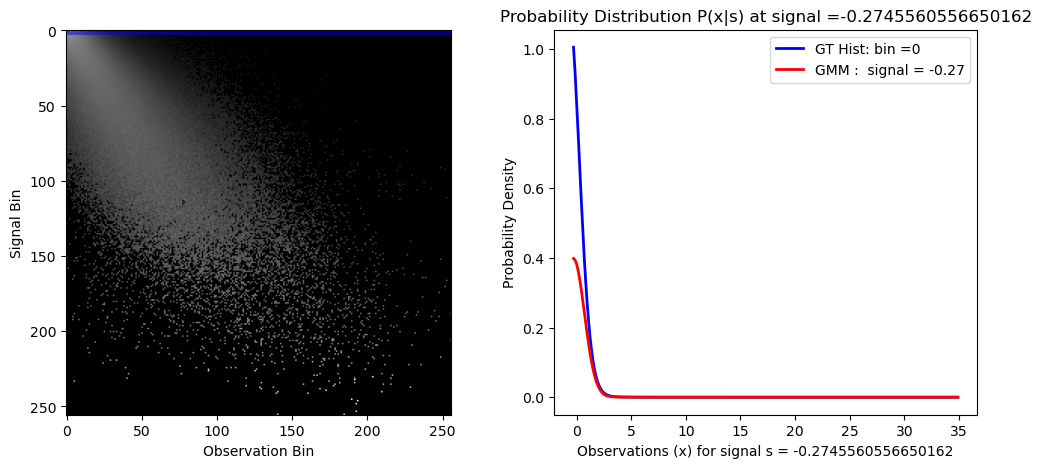

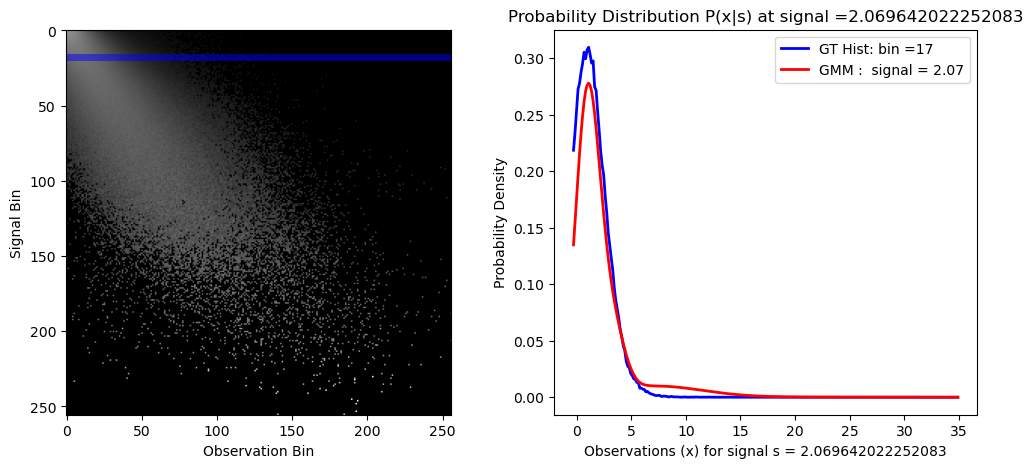

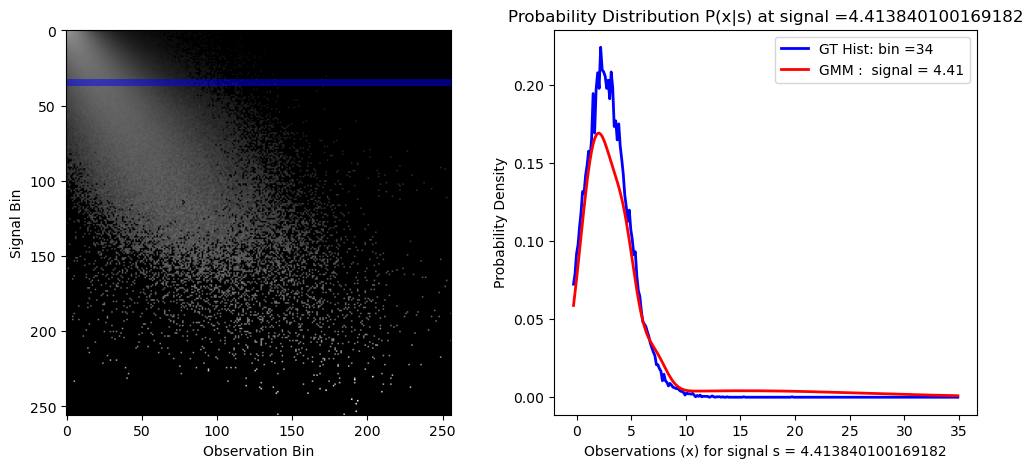

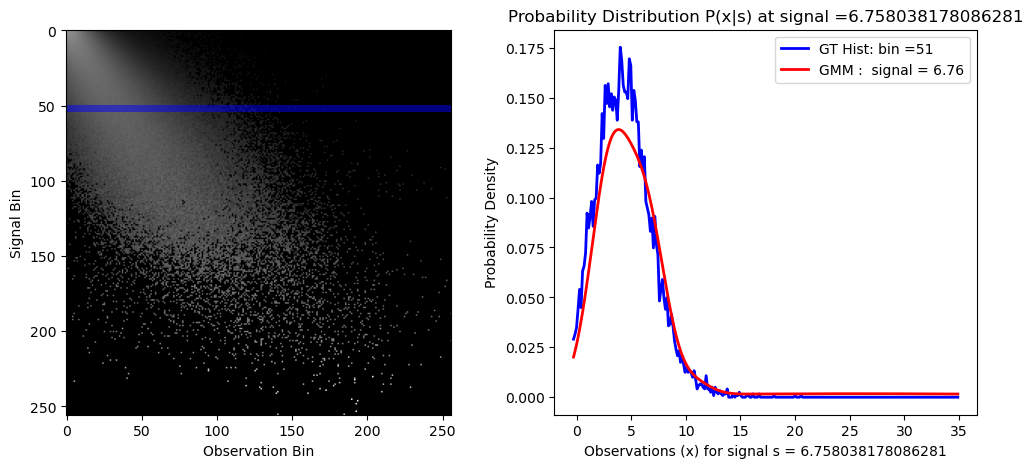

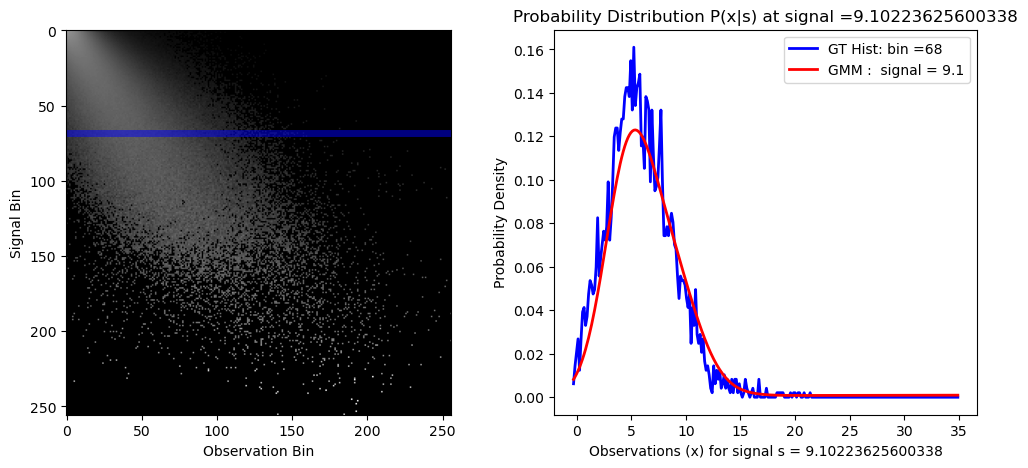

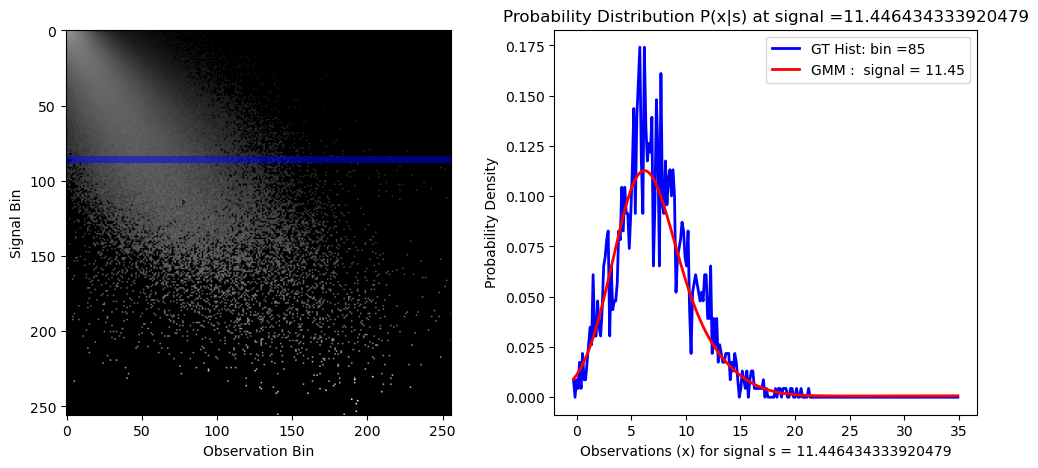

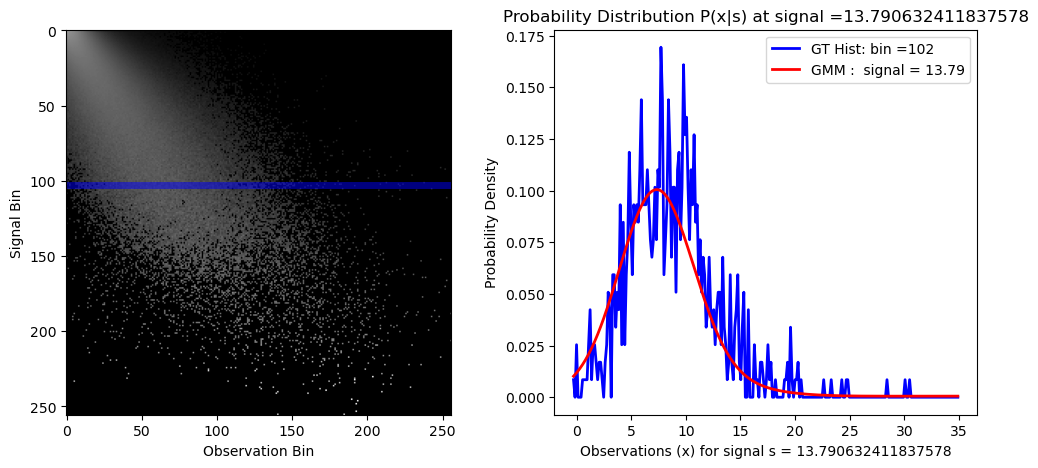

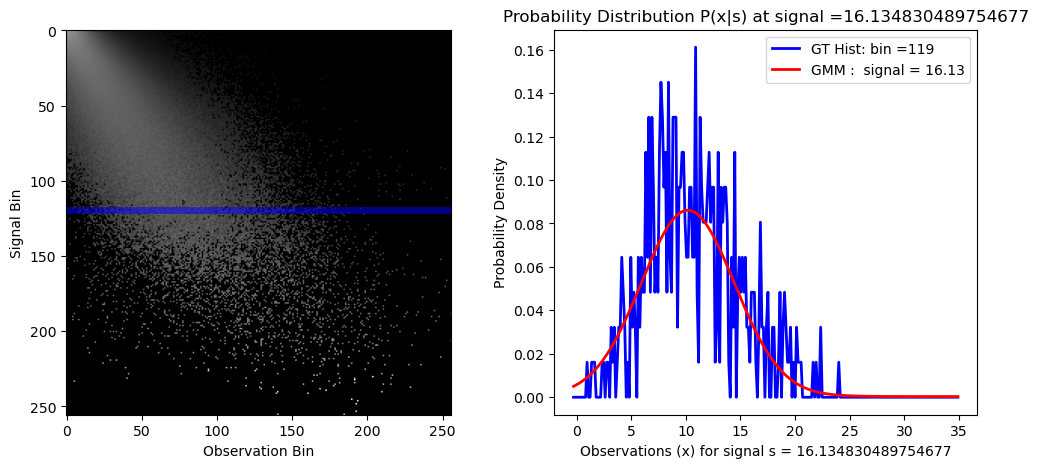

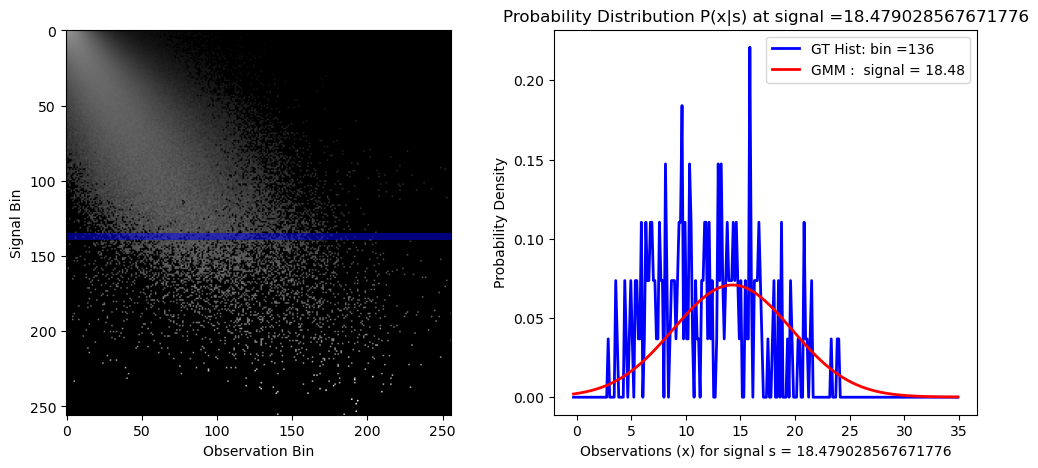

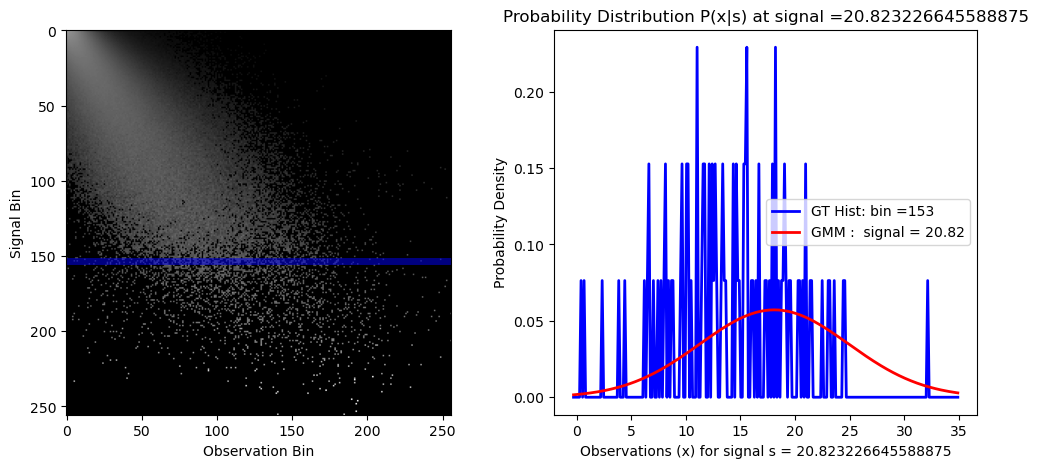

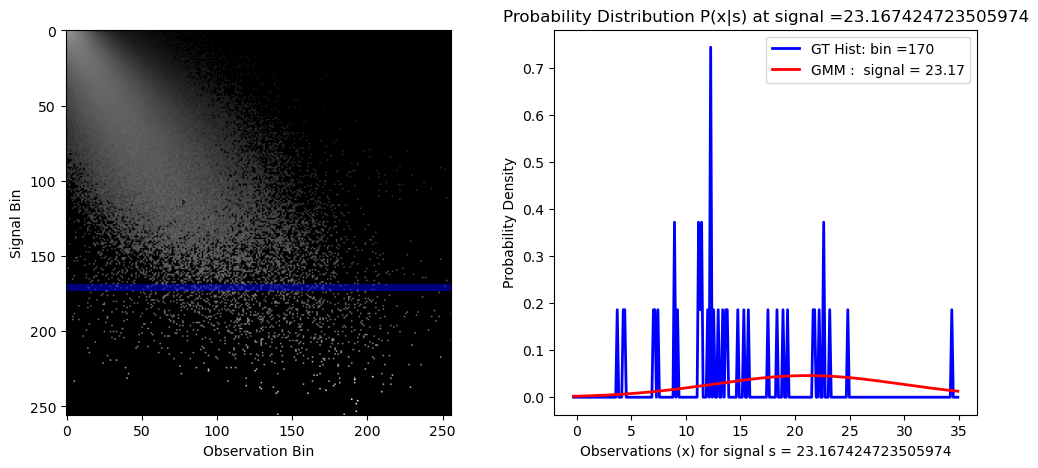

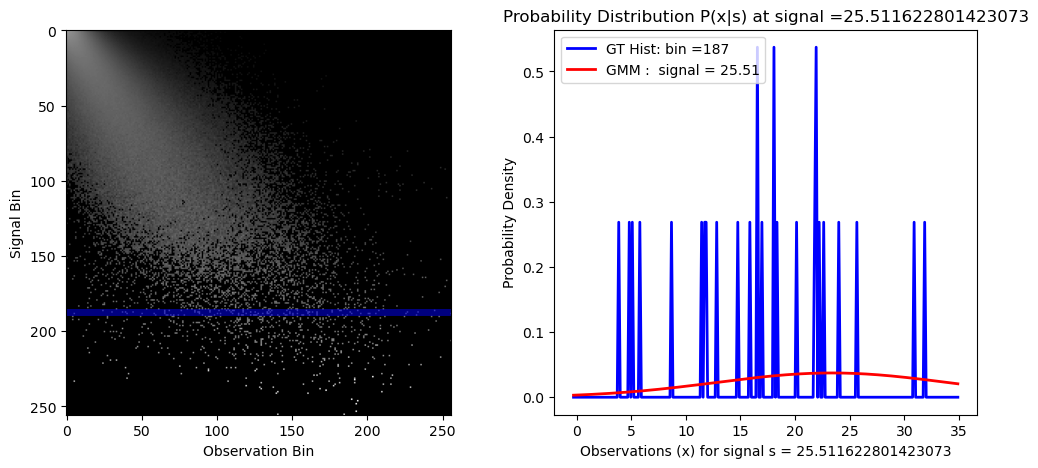

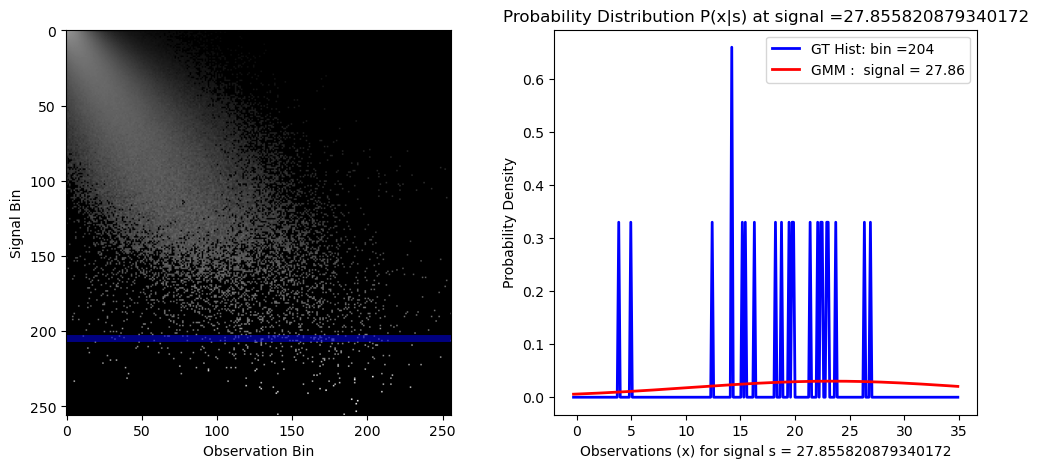

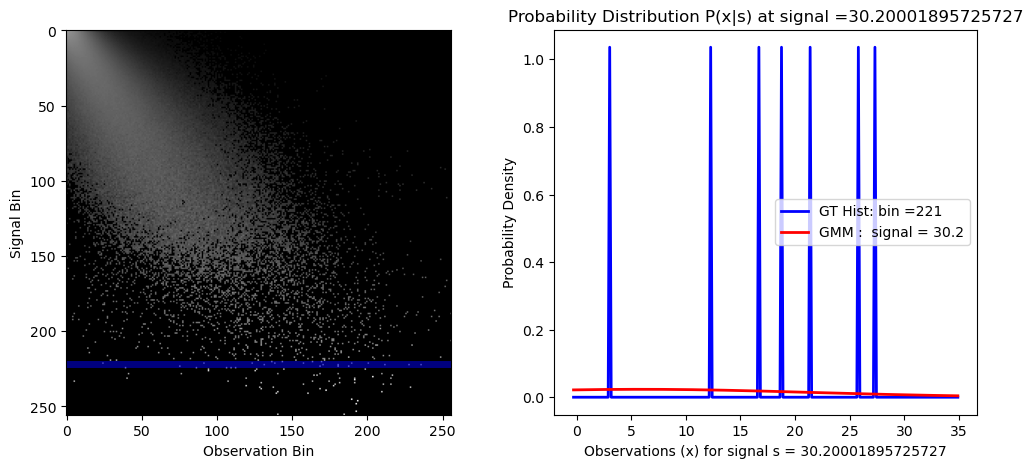

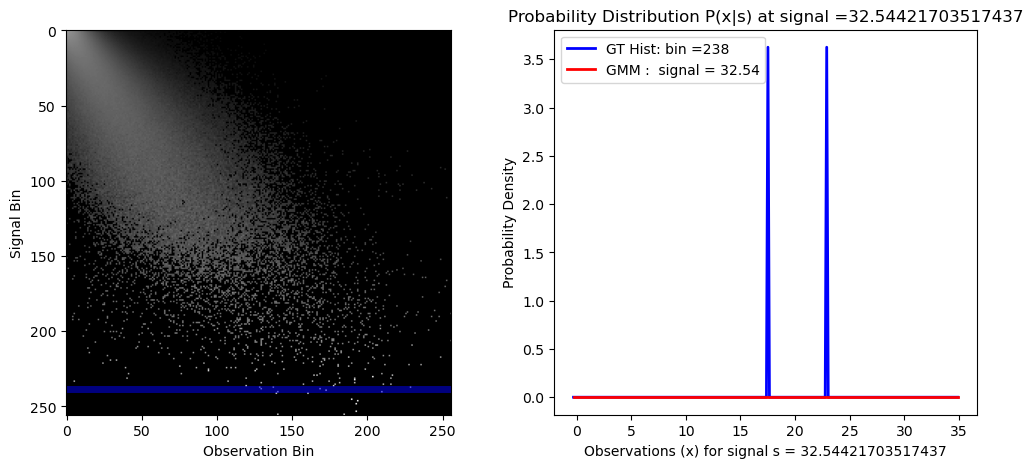

In [31]:
# Plot GMM
n_points = 15
signalBinIndex_list = (np.linspace(0,n_points-1,n_points)*hist_bins//n_points).astype(int)
for binidx in signalBinIndex_list:
    plotProbabilityDistribution(signalBinIndex=int(binidx), histogram=histogram[0], gaussianMixtureNoiseModel=noiseModel, min_signal=minVal, max_signal=maxVal, n_bin=hist_bins, device=device)